In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("student_placement_prediction_dataset_2026.csv")

In [3]:
df.head()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  object 
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  object 
 5   college_tier               100000 non-null  object 
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100

In [5]:
df.isnull().sum()

student_id                   0
age                          0
gender                       0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
coding_skill_score           0
aptitude_score               0
communication_skill_score    0
logical_reasoning_score      0
hackathons_participated      0
github_repos                 0
linkedin_connections         0
mock_interview_score         0
attendance_percentage        0
backlogs                     0
extracurricular_score        0
leadership_score             0
volunteer_experience         0
sleep_hours                  0
study_hours_per_day          0
placement_status             0
salary_package_lpa           0
dtype: int64

In [6]:
df.drop(columns=[
    "student_id", "age","sleep_hours","linkedin_connections","github_repos","extracurricular_score",
    "volunteer_experience"], inplace=True)

In [7]:
df.head()

,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,hackathons_participated,mock_interview_score,attendance_percentage,backlogs,leadership_score,study_hours_per_day,placement_status,salary_package_lpa
0,Male,7.53,IT,Tier 2,4,6,1,99.238568,81.707722,57.707166,59.070073,4,72.647009,77.463863,2,52.938240,3.6,Not Placed,0.00
1,Male,7.92,CSE,Tier 2,1,3,6,80.966123,63.116715,59.197085,78.976419,0,61.699110,88.887600,1,60.198856,2.3,Not Placed,0.00
2,Female,8.60,EEE,Tier 1,0,1,1,49.177184,48.658753,92.104885,80.603331,0,87.396911,74.153265,0,43.708803,5.9,Placed,11.99
3,Male,6.68,CSE,Tier 1,0,2,2,79.359084,66.376653,83.411798,64.187246,1,58.401069,87.635955,1,56.549154,4.4,Not Placed,0.00
4,Female,8.43,IT,Tier 3,1,4,3,65.018573,61.274985,88.956331,56.163678,1,74.489201,79.120749,1,67.268893,3.4,Placed,12.16


In [8]:
df["salary_package_lpa"].max()

20.44

In [9]:
df["college_tier"]=df["college_tier"].map({"Tier 1":1,"Tier 2":2,"Tier 3":3})

In [10]:
df["placement_status"]=df["placement_status"].map({"Placed":1,"Not Placed":0})

In [11]:
df["gender"]=df["gender"].map({"Male":1, "Female":0})

In [12]:
df = pd.get_dummies(df, columns=['branch'], drop_first=True)

In [13]:
df.head()

,gender,cgpa,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,...,backlogs,leadership_score,study_hours_per_day,placement_status,salary_package_lpa,branch_Civil,branch_ECE,branch_EEE,branch_IT,branch_Mechanical
0,1,7.53,2,4,6,1,99.238568,81.707722,57.707166,59.070073,...,2,52.938240,3.6,0,0.00,False,False,False,True,False
1,1,7.92,2,1,3,6,80.966123,63.116715,59.197085,78.976419,...,1,60.198856,2.3,0,0.00,False,False,False,False,False
2,0,8.60,1,0,1,1,49.177184,48.658753,92.104885,80.603331,...,0,43.708803,5.9,1,11.99,False,False,True,False,False
3,1,6.68,1,0,2,2,79.359084,66.376653,83.411798,64.187246,...,1,56.549154,4.4,0,0.00,False,False,False,False,False
4,0,8.43,3,1,4,3,65.018573,61.274985,88.956331,56.163678,...,1,67.268893,3.4,1,12.16,False,False,False,True,False


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   gender                     100000 non-null  int64  
 1   cgpa                       100000 non-null  float64
 2   college_tier               100000 non-null  int64  
 3   internships_count          100000 non-null  int64  
 4   projects_count             100000 non-null  int64  
 5   certifications_count       100000 non-null  int64  
 6   coding_skill_score         100000 non-null  float64
 7   aptitude_score             100000 non-null  float64
 8   communication_skill_score  100000 non-null  float64
 9   logical_reasoning_score    100000 non-null  float64
 10  hackathons_participated    100000 non-null  int64  
 11  mock_interview_score       100000 non-null  float64
 12  attendance_percentage      100000 non-null  float64
 13  backlogs                   100

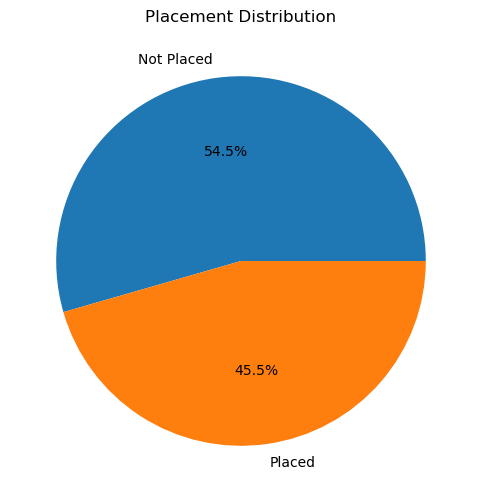

In [15]:
plt.figure(figsize=(6,6))
df['placement_status'].value_counts().plot(kind='pie',autopct='%1.1f%%',labels=['Not Placed', 'Placed'])
plt.title("Placement Distribution")
plt.ylabel("")
plt.show()

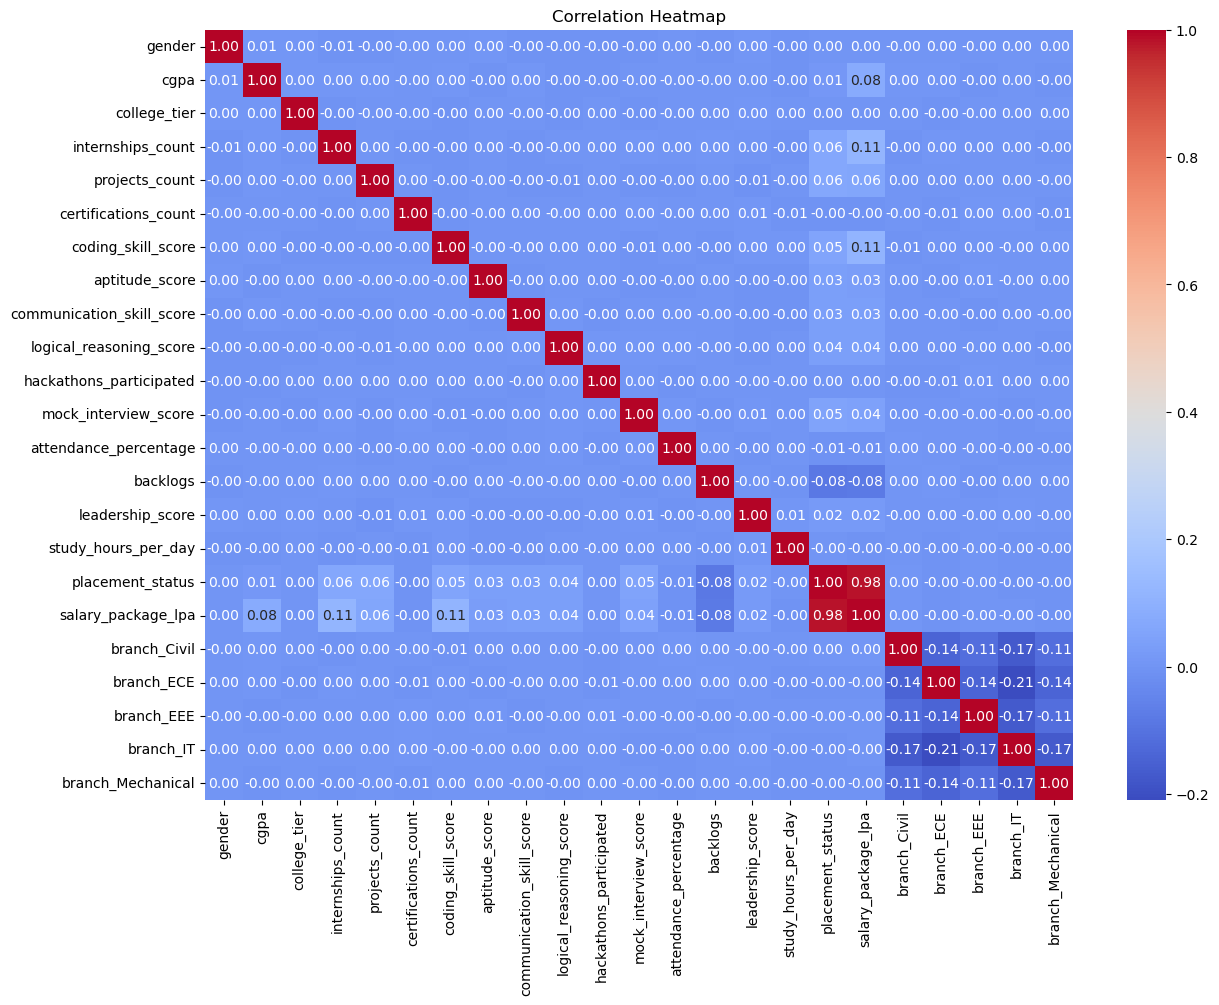

In [16]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [17]:
x=df.drop(columns=["placement_status","salary_package_lpa"])
y=df["placement_status"]

In [18]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [19]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [20]:
from sklearn.linear_model import LogisticRegression
placement_model=LogisticRegression(max_iter=1000)
placement_model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [21]:
y_pred=placement_model.predict(x_test)

In [22]:
from sklearn.metrics import accuracy_score
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.5704


In [23]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.55      0.33      0.41      9127
           1       0.58      0.78      0.66     10873

    accuracy                           0.57     20000
   macro avg       0.56      0.55      0.54     20000
weighted avg       0.57      0.57      0.55     20000



In [24]:
salary_df = df[df['placement_status'] == 1]

In [25]:
X_salary = salary_df.drop(columns=['placement_status', 'salary_package_lpa'])
y_salary = salary_df['salary_package_lpa']

In [26]:
Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_salary,y_salary,test_size=0.2,random_state=42)

In [27]:
from sklearn.linear_model import LinearRegression
salary_model=LinearRegression()
salary_model.fit(Xs_train, ys_train)

LinearRegression()

In [28]:
salary_pred = salary_model.predict(Xs_test)

In [29]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

print("MAE:", mean_absolute_error(ys_test, salary_pred))
print("RMSE:", np.sqrt(mean_squared_error(ys_test, salary_pred)))
print("R2 Score:", r2_score(ys_test, salary_pred))

MAE: 0.7980705813613282
RMSE: 0.9988128903552462
R2 Score: 0.6061920467973841


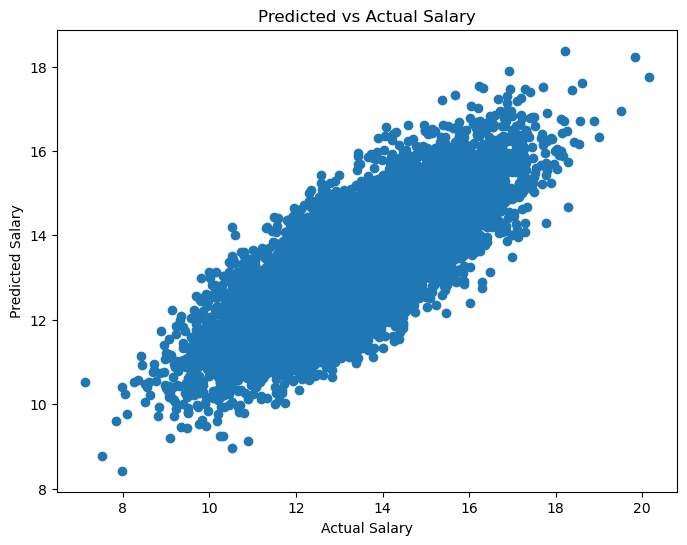

In [30]:
plt.figure(figsize=(8,6))
plt.scatter(ys_test, salary_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Predicted vs Actual Salary")
plt.show()

In [31]:
import pickle
import os

feature_cols = x.columns.tolist()

with open('placement_model.pkl', 'wb') as f: pickle.dump(placement_model, f)
with open('salary_model.pkl',    'wb') as f: pickle.dump(salary_model,    f)
with open('scaler.pkl',          'wb') as f: pickle.dump(scaler,          f)
with open('feature_columns.pkl', 'wb') as f: pickle.dump(feature_cols,    f)

print("Saved!")
print("Location:", os.getcwd())

Saved!
Location: C:\Users\harin\Projects\Logistic Regression
